In [3]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from PLIs import *
from GW_detectors import GW_detectors


In [13]:
et_data = np.genfromtxt('ET-0000A-18_ETDSensitivityCurveTxtFile.txt')
print(et_data)

freq_et = [a[0] for a in et_data]

[[1.0000000e+00 5.6360987e-17 4.4569531e-17 3.4959517e-17]
 [1.0030759e+00 5.4061732e-17 4.6943421e-17 3.5445436e-17]
 [1.0061612e+00 5.1776256e-17 4.9548476e-17 3.5797734e-17]
 ...
 [9.9387655e+03 2.6855851e-20 5.3888364e-24 5.3888363e-24]
 [9.9693357e+03 2.7128723e-20 5.4060172e-24 5.4060171e-24]
 [1.0000000e+04 2.7404325e-20 5.4232615e-24 5.4232613e-24]]


In [2]:
with open('muAres_1908.11391.csv','rb') as f:
    a = []
    for line in f:
        b = str(line).strip('b')
        c = b.split(',')
        #print(c[0], c[1])
        a.append(c)
    
print(a[1])

["'-6.9796410509", "-10.1967081052\\n'"]


In [3]:
b = a[1:]
f_muares = [-float(b[i][0][2:-1]) for i in range(len(b))]
omega_muares = [-float(b[i][1][1:-3]) for i in range(len(b))]
print(omega_muares)

[-10.1967081052, -10.4110871498, -10.653675538, -10.8741503382, -11.0770897692, -11.3250442512, -11.55130411, -11.7736236046, -11.9959430992, -12.2132852917, -12.4264797324, -12.6363559718, -12.8393192915, -13.0361992419, -13.2253367224, -13.4081834461, -13.5825272786, -13.7479534448, -13.9088862133, -14.063182579, -14.2053122061, -14.3401141385, -14.4663440505, -14.5775037978, -14.6618414171, -14.7202555878, -14.7409252174, -14.7193569082, -14.6555506602, -14.5674800644, -14.4560438003, -14.3153658863, -14.1253988554, -13.8607722928, -13.5330999034, -13.1745267633, -12.7970813527, -12.4106491465, -12.02511562, -11.6331279403, -11.239669694, -10.8496427697, -10.4596158454, -10.0615008052, -9.6714738808, -9.2823456361, -8.8905213527, -8.4959193325, -8.1014807085, -7.7096564251, -7.3205281804, -6.9263346509, -6.5305888567, -6.1405619324, -5.7505350081, -5.3567499693, -4.9605956844, -4.5714674396, -4.1823391948, -3.78618491, -3.3950142117, -3.0014742673, -2.611447343, -2.2214204187, -1.82

In [65]:
for f in f_muares:
    print(10**f)

1.047994371081526e-07
1.3240330928964893e-07
1.7506237819738258e-07
2.300088613377497e-07
2.998600672108728e-07
3.93274347344079e-07
5.131650425233007e-07
6.741889404855457e-07
8.85739847343145e-07
1.1636724245474875e-06
1.5498209597956097e-06
2.036132753098532e-06
2.693356012446125e-06
3.5627179099416934e-06
4.74495637620183e-06
6.2765341771632865e-06
8.359314887455416e-06
1.1209457300923363e-05
1.4929160050914313e-05
1.9883194552215852e-05
2.6662450550856226e-05
3.5997892773508523e-05
4.827152062955251e-05
6.517304252744452e-05
8.859477815755188e-05
0.00011961486129435739
0.0001626017704522144
0.00022103721501636397
0.0002984299560768289
0.0004029205619628074
0.0005439969264909074
0.00072947489135555
0.0009715410045117225
0.0012590978055185516
0.0015770382537160994
0.0019352436361577846
0.0023426253577700654
0.0028357636484089414
0.003386187443892258
0.004071130960243859
0.0048946219109009745
0.0058446715989860535
0.006979126625473334
0.008448279412888868
0.010088096617808217
0.01204

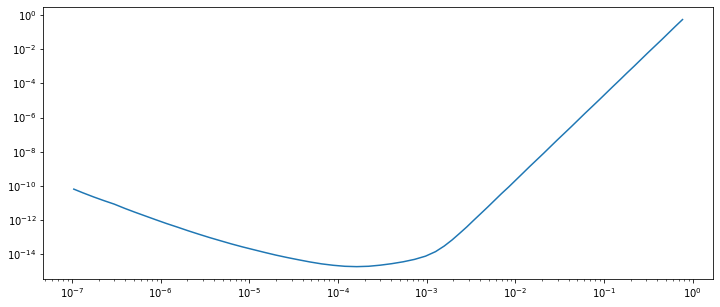

In [67]:
fig, ax = plt.subplots(figsize = (12,5))
ax.plot(10**np.array(f_muares), 10**np.array(omega_muares))
ax.set_xscale('log')
ax.set_yscale('log')

In [8]:
freq_lisa = np.linspace(3e-5,0.5,1000000)
freq_decigo = np.linspace(1e-3,100,1000000)
freq_bbo = np.linspace(1e-3,100,1000000)
freq_bdecigo = np.linspace(1e-2,100,1000000)
freq_ska = np.linspace(1/(20 * 365 * 24 * 3600), 1/14*24*3600, 1000000)

lisa_spec = GW_detectors('lisa', freq_lisa).spectral_density()
decigo_spec = [GW_detectors('decigo',f).spectral_density() for f in freq_decigo]
bdecigo_spec = GW_detectors('bdecigo',freq_bdecigo).spectral_density()
bbo_spec = [GW_detectors('bbo', f).spectral_density() for f in freq_bbo]
ska_20_spec = GW_detectors('ska', freq_ska).spectral_density()
et_spec = GW_detectors('et', None).spectral_density()

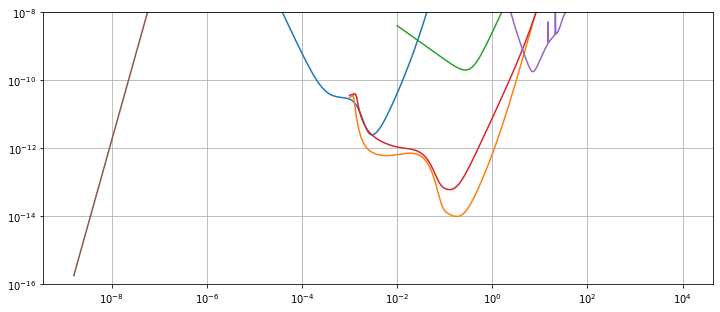

In [18]:
fig, ax = plt.subplots(figsize = (12,5))
ax.plot(freq_lisa, lisa_spec)
ax.plot(freq_bbo, bbo_spec)
ax.plot(freq_bdecigo, bdecigo_spec)
ax.plot(freq_decigo, decigo_spec)
ax.plot(freq_et, et_spec)
ax.plot(freq_ska, ska_20_spec)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-16, 1e-8)
ax.grid()

In [19]:
pickle.dump([freq_lisa, lisa_spec], open('lisa_spec.p','wb'))
pickle.dump([freq_bbo, bbo_spec], open('bbo_spec.p','wb'))
pickle.dump([freq_bdecigo, bdecigo_spec], open('bdecigo_spec.p','wb'))
pickle.dump([freq_decigo, decigo_spec], open('decigo_spec.p','wb'))
pickle.dump([freq_et, et_spec], open('et_spec.p','wb'))
pickle.dump([freq_ska, ska_20_spec], open('ska20_spec.p','wb'))


In [7]:
lisa_pli = PLI_curves(3e-5,0.5,-5,3,-8,8,'lisa',4,10).maximise_p()
decigo_pli = PLI_curves(1e-3, 100, -3, 2, -8,8, 'decigo', 4, 10).maximise_p()
bbo = PLI_curves(1e-3, 100, -3, 2, -3, 10, 'bbo', 4, 10).maximise_p()

In [3]:
delta_t = 14*24*3600
fmin1 = 1/(5 * 365 * 24 * 3600)
fmin2 = 1/(10 * 365 * 24 * 3600)
fmin3 = 1/(20 * 365 * 24 * 3600)

fmax = 1/delta_t
ska5 = PLI_curves(fmin1, fmax, -9, -6, -8, 8, 'ska', 5, 4).maximise_p()
ska10 = PLI_curves(fmin2, fmax, -9, -6, -8, 8, 'ska', 10, 4).maximise_p()
ska20 = PLI_curves(fmin3, fmax, -9, -6, -8, 8, 'ska', 20, 4).maximise_p()

In [13]:
pickle.dump(lisa_pli, open('lisa_pli.p','wb'))
pickle.dump(bdecigo_pli, open('bdecigo_pli.p','wb'))
pickle.dump(decigo_pli, open('decigo_pli.p','wb'))
pickle.dump(bbo, open('bbo_pli.p','wb'))
pickle.dump(ska5, open('ska5_pli.p','wb'))
pickle.dump(ska10, open('ska10_pli.p','wb'))
pickle.dump(ska20, open('ska20_pli.p','wb'))

In [11]:
bdecigo_pli = PLI_curves(1e-2, 100, -2, 2, -2, 8, 'bdecigo', 4, 8).maximise_p()

(1e-17, 1e-07)

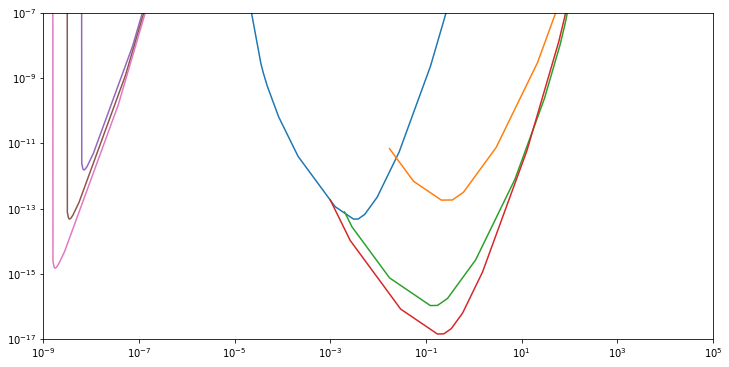

In [12]:
fig, ax = plt.subplots(figsize = (12,6))
ax.plot(lisa_pli[0],lisa_pli[1])
ax.plot(bdecigo_pli[0][6000:],bdecigo_pli[1][6000:])

ax.plot(decigo_pli[0][6000:],decigo_pli[1][6000:])
ax.plot(bbo[0][1:],bbo[1][1:])
ax.plot(ska5[0], ska5[1])
ax.plot(ska10[0], ska10[1])
ax.plot(ska20[0], ska20[1])

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlim(1e-9, 1e5)
ax.set_ylim(1e-17, 1e-7)

In [100]:
def test(f):
    sigma = 100e-9
    delta_t = 14*24*3600
    N_p = 1000
    H_0 =  0.674 * 100 * 3.24e-20  
    return 0.67**2 * np.sqrt(2/(N_p*(N_p-1))) * (64 * np.sqrt(3) * np.pi**4 * sigma**2 * delta_t * f**5)/H_0**2

def test2(f):
    sigma = 100e-9
    delta_t = 14*24*3600
    N_p = 1000
    H_0 =  100 * 3.086e-20
    return 96 * np.sqrt(3) * np.pi**2 * f**2 * sigma**2 * delta_t * np.sqrt(2/(N_p*(N_p-2)))

In [103]:
sigma = 100e-9
delta_t = 14*24*3600
N_p = 1000
H_0 = 100 * 3.086e-19
H_0 = 0.674 * 100 * 3.24e-20  

fmin1 = 1/(5 * 365 * 24 * 3600)
fmin2 = 1/(10 * 365 * 24 * 3600)
fmin3 = 1/(20 * 365 * 24 * 3600)

fmax = 1/delta_t
f = np.linspace(fmin1, fmax, 1000)

(1e-15, 0.001)

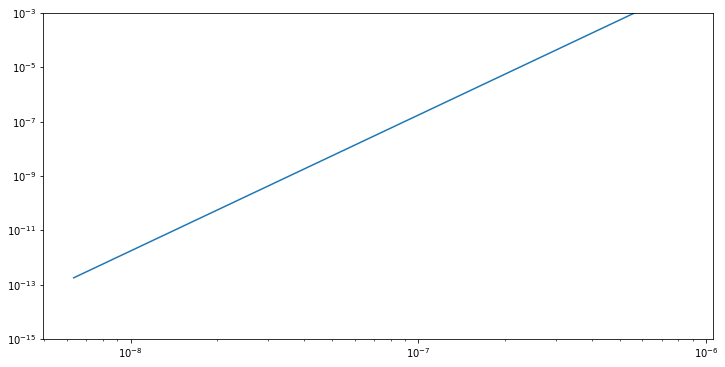

In [104]:
fig, ax = plt.subplots(figsize = (12,6))
ax.plot(f, test(f))
#ax.plot(f, test2(f))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-15, 1e-3)

In [4]:
def homega_eff(f, S):
    return 0.674**2 * 2*np.pi**2/(3*(100e3/3.086e22)**2) * f**3 * S**2

In [5]:
et_data = np.genfromtxt('ET-0000A-18_ETDSensitivityCurveTxtFile.txt')
print(et_data)

freq = [a[0] for a in et_data]
test1 = [a[1] for a in et_data]
test2 = [a[2] for a in et_data]
test3 = [a[3] for a in et_data]
print(len(freq))

[[1.0000000e+00 5.6360987e-17 4.4569531e-17 3.4959517e-17]
 [1.0030759e+00 5.4061732e-17 4.6943421e-17 3.5445436e-17]
 [1.0061612e+00 5.1776256e-17 4.9548476e-17 3.5797734e-17]
 ...
 [9.9387655e+03 2.6855851e-20 5.3888364e-24 5.3888363e-24]
 [9.9693357e+03 2.7128723e-20 5.4060172e-24 5.4060171e-24]
 [1.0000000e+04 2.7404325e-20 5.4232615e-24 5.4232613e-24]]
3000


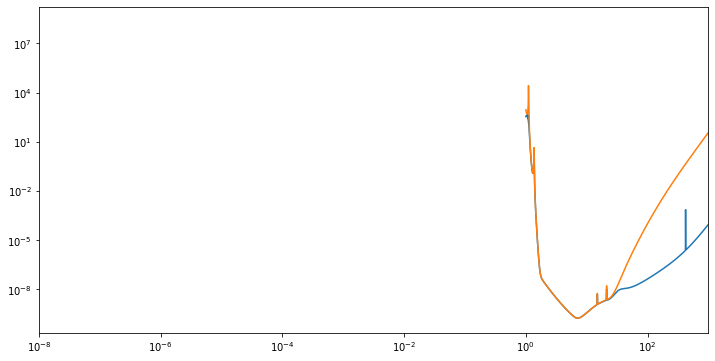

In [11]:
fig, ax = plt.subplots(figsize = (12,6))
ax.plot(freq, homega_eff(np.array(freq), np.array(test3)))
ax.plot(freq, homega_eff(np.array(freq), np.array(test1)))

#ax.plot(freq, test)
#ax.plot(freq, test2)
#ax.plot(freq, test3)
ax.set_xlim(1e-8, 1e3)
ax.set_yscale('log')
ax.set_xscale('log')

In [4]:
test = 10**np.array(omega_muares)

In [5]:
freq = 10**np.array(f_muares)

In [6]:
powers = np.arange(-8,8,1)

f0 = 1
def spec_ratio(p,i):
    return ((freq[i]/f0)**p /test[i])**2

omega_threshs = []
for p in powers:
    SNR_thresh = sum((freq[i+1]-freq[i]) * spec_ratio(p,i) for i in range(len(freq)-1))
   
    omega_threshs.append(SNR_thresh**(-1/2))

In [7]:
PLIs=  []
for f in freq:
    temp = []
    for p in range(len(powers)):
        temp.append((10 /np.sqrt(7 * 365 * 24 * 3600)) * omega_threshs[p] * (f/f0)**powers[p])                   
    PLIs.append(max(temp))




In [8]:
muares_spec = [10**np.array(f_muares), 10**np.array(omega_muares)]
#pickle.dump(muares_spec, open('muares_spec.p','wb'))

(1e-18, 1e-08)

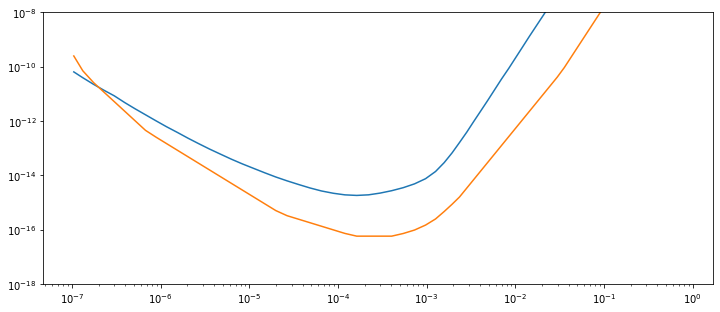

In [9]:
fig, ax = plt.subplots(figsize = (12,5))
ax.plot(10**np.array(f_muares), 10**np.array(omega_muares))
ax.plot(freq, PLIs)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim(1e-18,1e-8)

In [10]:
mu_ares_pli = [freq, PLIs]

In [11]:
pickle.dump(mu_ares_pli, open('mu_ares_pli.p','wb'))
